# **Figure 6: Singular Decision Tree from Random Forest**

Imports

In [1]:
from collections import Counter
from datetime import datetime
from dateutil import parser
from itertools import combinations
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import pandas as pd
import re
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

Download Benign Domains

In [2]:
cisco_path = kagglehub.dataset_download("adebayo/cisco-umbrella-list")
cisco_path += "/top-1m.csv"
print(cisco_path)

C:\Users\Admin\.cache\kagglehub\datasets\adebayo\cisco-umbrella-list\versions\1/top-1m.csv


Download Malicious DGA Domains

In [3]:
dga_path = kagglehub.dataset_download("gtkcyber/dga-dataset")
dga_path += "/dga_data.csv"
print(dga_path)

C:\Users\Admin\.cache\kagglehub\datasets\gtkcyber\dga-dataset\versions\1/dga_data.csv


Load Datasets

In [4]:
benign_domains = pd.read_csv(cisco_path, header=None)
benign_domains.columns = ["rank", "domain"]
benign_domains["label"] = 0

dga_domains = pd.read_csv(dga_path)
dga_domains["label"] = dga_domains["subclass"].apply(lambda x: 0 if x in ["alexa", "legit"] else 1)
# remove fake DGAs
dga_domains = dga_domains[dga_domains["label"] == 1]

print("Length of Benign Domain dataset:", len(benign_domains))
print("Length of DGA Domain dataset:", len(dga_domains))

benign_sample = benign_domains[["domain", "label"]]
dga_sample = dga_domains[["domain", "label"]]
benign_sampler = benign_domains[["domain", "label"]].sample(n=len(dga_sample), random_state=60)
df_full = pd.concat([benign_sample, dga_sample], ignore_index=True)
df = pd.concat([benign_sampler, dga_sample], ignore_index=True)
# Drop any rows with missing domains
print("Missing domains (benign):", benign_sample["domain"].isna().sum())
print("Missing domains (DGA):   ", dga_sample["domain"].isna().sum())
df = df.dropna(subset=["domain"]).reset_index(drop=True)
df["domain"] = df["domain"].astype(str).str.lower()
df_full = df_full.dropna(subset=["domain"]).reset_index(drop=True)
df_full["domain"] = df_full["domain"].astype(str).str.lower()

print("\nClass balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Length of Benign Domain dataset: 1000000
Length of DGA Domain dataset: 80000
Missing domains (benign): 0
Missing domains (DGA):    0

Class balance:
label
0    80000
1    80000
Name: count, dtype: int64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


Extract Features

In [5]:
def shannon_entropy(s):
    """Measures randomness of characters in a string. Higher = more random."""
    if not s:
        return 0.0
    counts = Counter(s)
    length = len(s)
    return -sum((c/length) * math.log2(c/length) for c in counts.values())

def vowel_ratio(s):
    if not s:
        return 0.0
    vowels = sum(1 for ch in s if ch in "aeiou")
    letters = sum(1 for ch in s if ch.isalpha())
    return vowels / letters if letters else 0.0

def digit_ratio(s):
    if not s:
        return 0.0
    return sum(1 for ch in s if ch.isdigit()) / len(s)

def max_consecutive_consonants(s):
    rows = re.findall(r'[^aeiou\d\W_]+', s)
    maximum = max((len(r) for r in rows), default=0)
    return maximum

def hex_valid_ratio(s):
    if(not s):
        return 0
    return sum(1 for ch in s if ch in '0123456789abcdef') / len(s)

def is_dword_value(s):
    return int(bool(re.fullmatch(r'[0-9a-f]{8}', s)))

def max_consecutive_digits(s):
    rows = re.findall(r'\d+', s)
    maximum = max((len(r) for r in rows), default=0)
    return maximum

def is_punycode(domain):
    return int(any(label.startswith('xn--') for label in domain.split('.')))

def subdomain_count(domain):
    return len(domain.split('.')) - 1

# top-level domain
def tld_detection(df):
    tlds = df.groupby("tld")["label"]
    tld_counts = tlds.count()
    tld_sums = tlds.sum()
    # Laplace Smoothing - Benign and DGA (2)
    tld_malicious_laplace_smoothed = (tld_sums + 1) / (tld_counts + 2)
    return tld_malicious_laplace_smoothed
    # return df["tld"].map(tld_malicious_laplace_smoothed)

def has_embedded_date(s):
    no_date = datetime(1900, 1, 1)
    try:
        result = parser.parse(s, fuzzy=True, default=no_date)
        if(result.date() == no_date.date()):
            return 0
        return 1
    except (ValueError, parser.ParserError, OverflowError):
        return 0
    
def cons_vowel_transition_rate(s):
    def is_vowel(character):
        return (character in 'aeiou')
    
    # we want to ignore digits and hyphens
    alpha = [ch for ch in s if ch.isalpha()] 
    if(len(alpha) < 2):
        return 0.0
    curr_v = is_vowel(alpha[0])
    trans_count = 0
    if(curr_v):
        vowel_count = 1
    else:
        vowel_count = 0

    for ch in alpha[1:]:
        typing = is_vowel(ch)
        if(typing):
            vowel_count += 1
        # if a change in vowel to consonant or vice-versa, it is a transition
        if(typing != curr_v):
            trans_count += 1
            curr_v = typing

    if(vowel_count < 2):
        return 0.0
    return trans_count / (vowel_count - 1)

def char_class_entropy(s):
    def classify(ch):
        # if a vowel
        if(ch in 'aeiou'):
            return 'V'
        # otherwise if a letter, it is a consonant
        elif(ch.isalpha()):
            return 'C'
        # if it is a number
        elif(ch.isdigit()):
            return 'D'
        # if it is a special character, like a hyphen
        else:
            return 'H'
    classes = ''.join(classify(ch) for ch in s)
    return shannon_entropy(classes)

df["name"] = df["domain"].str.split(".").str[0]
df["tld"] = df["domain"].str.split(".").str[-1]
df_full["tld"] = df_full["domain"].str.split(".").str[-1]
df["length"] = df["name"].str.len()
df["entropy"] = df["name"].apply(shannon_entropy)
df["vowel_ratio"] = df["name"].apply(vowel_ratio)
df["digit_ratio"] = df["name"].apply(digit_ratio)
df["unique_chars"] = df["name"].apply(lambda s: len(set(s)))
df["hyphen_count"] = df["name"].str.count('-')
df["max_consec_cons"] = df["name"].apply(max_consecutive_consonants)
df["hex_ratio"] = df["name"].apply(hex_valid_ratio)
df["dword"] = df["name"].apply(is_dword_value)
df["max_consec_digit"] = df["name"].apply(max_consecutive_digits)
df["puny_code"] = df["domain"].apply(is_punycode)
df["subdomain_count"] = df["domain"].apply(subdomain_count)
tld_rates = tld_detection(df_full)
df["mal_tld"] = df["tld"].map(tld_rates).fillna(0.35)
df["embed_date"] = df["name"].apply(has_embedded_date)
df["cons_vowel_transition_rate"] = df["name"].apply(cons_vowel_transition_rate)
df["char_class_entropy"] = df["name"].apply(char_class_entropy)


In [6]:
X = df[["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "mal_tld", "embed_date", "cons_vowel_transition_rate", "char_class_entropy"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

Find the best combination of features

In [7]:
def create_best_feature_importance(best_n, ver, color):
    best_clf = RandomForestClassifier(n_estimators=best_n, random_state=60)
    best_clf.fit(X_train, y_train)
    # feature_importance = pd.Series(best_clf.feature_importances_, index=X_best.columns).sort_values(ascending=False)
    # print("Feature Importance:\n" + str(feature_importance))
    # plt.figure(figsize=(12, 6))
    # feature_importance.plot(kind="bar", color=color)
    # plt.xlabel("Feature", fontsize=14)
    # plt.ylabel("Importance Score", fontsize=14)
    # plt.title(f"Random Forest Feature Importance ({ver} Metric)", fontsize=16, fontweight="bold")
    # plt.xticks(rotation=0, fontsize=12)
    # plt.yticks(fontsize=12)
    # plt.tight_layout()
    # plt.savefig(f"feature_importance_{ver}_{_section}_fixed.pdf", format="pdf", bbox_inches="tight")
    # plt.show()

    single_tree = best_clf.estimators_[0]
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(
        single_tree,
        feature_names=X_best.columns.tolist(),
        class_names=["Benign", "DGA"],
        filled=True,
        rounded=True,
        max_depth=2,
        fontsize=15,
        ax=ax
    )
    for artist in ax.get_children():
        if hasattr(artist, 'get_bbox_patch'):
            bp = artist.get_bbox_patch()
            if bp is not None:
                bp.set_edgecolor("black")
                bp.set_linewidth(1.5)
    plt.title(f"Singular Decision Tree from Random Forest (max_depth=2) ({ver} Metric)", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"../../figures/decision_tree.pdf", format="pdf", bbox_inches="tight")
    plt.show()

Combinations without Malicious TLDs

In [8]:
features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars", "hyphen_count", "max_consec_cons", "hex_ratio", "dword", "max_consec_digit", "puny_code", "subdomain_count", "embed_date"]

benign = df[df["label"] == 0].sample(n=25000, random_state=60)
dga = df[df["label"] == 1].sample(n=25000, random_state=60)
df_sample = pd.concat([benign, dga]).sample(frac=1, random_state=60)
# df_sample = df.sample(n=50000, random_state=60)
y = df_sample["label"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=60)
results = []
sample_n_estimators = 20
# test combinations of 3 to 8
for size in range(3, 9):
    for combo in combinations(features, size):
        X_sub = df_sample[list(combo)]
        clf = RandomForestClassifier(n_estimators=sample_n_estimators, random_state=60, n_jobs=-1)
        cv_scores = cross_val_score(clf, X_sub, y, cv=cv, scoring="f1", n_jobs=-1)
        mean_f1 = cv_scores.mean()
        results.append((mean_f1, combo))


results.sort(reverse=True)
print("15 best feature combinations:")
for score, combo in results[:15]:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

15 best feature combinations:
    F1 Score=0.9999200159968007 | Length of Features:=8 | Features: ('length', 'vowel_ratio', 'digit_ratio', 'unique_chars', 'hyphen_count', 'hex_ratio', 'max_consec_digit', 'subdomain_count')
    F1 Score=0.9999200159968007 | Length of Features:=7 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_digit', 'puny_code', 'subdomain_count', 'embed_date')
    F1 Score=0.9999200159968007 | Length of Features:=6 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_digit', 'puny_code', 'subdomain_count')
    F1 Score=0.9999200159968007 | Length of Features:=7 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_cons', 'dword', 'subdomain_count', 'embed_date')
    F1 Score=0.9999200159968007 | Length of Features:=8 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit', 'puny_code', 'subdomain_count')
    F1 Score=0.9999200159968007 | Length of Features:=7 | Features: ('leng

In [9]:
for score, combo in results:
    print(f"    F1 Score={score} | Length of Features:={len(combo)} | Features: {combo}")

    F1 Score=0.9999200159968007 | Length of Features:=8 | Features: ('length', 'vowel_ratio', 'digit_ratio', 'unique_chars', 'hyphen_count', 'hex_ratio', 'max_consec_digit', 'subdomain_count')
    F1 Score=0.9999200159968007 | Length of Features:=7 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_digit', 'puny_code', 'subdomain_count', 'embed_date')
    F1 Score=0.9999200159968007 | Length of Features:=6 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_digit', 'puny_code', 'subdomain_count')
    F1 Score=0.9999200159968007 | Length of Features:=7 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_cons', 'dword', 'subdomain_count', 'embed_date')
    F1 Score=0.9999200159968007 | Length of Features:=8 | Features: ('length', 'unique_chars', 'hyphen_count', 'max_consec_cons', 'dword', 'max_consec_digit', 'puny_code', 'subdomain_count')
    F1 Score=0.9999200159968007 | Length of Features:=7 | Features: ('length', 'unique_chars', 'hyphen_c

In [10]:
best_score, best_combo = results[0]
X_best = df[list(best_combo)]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=60)

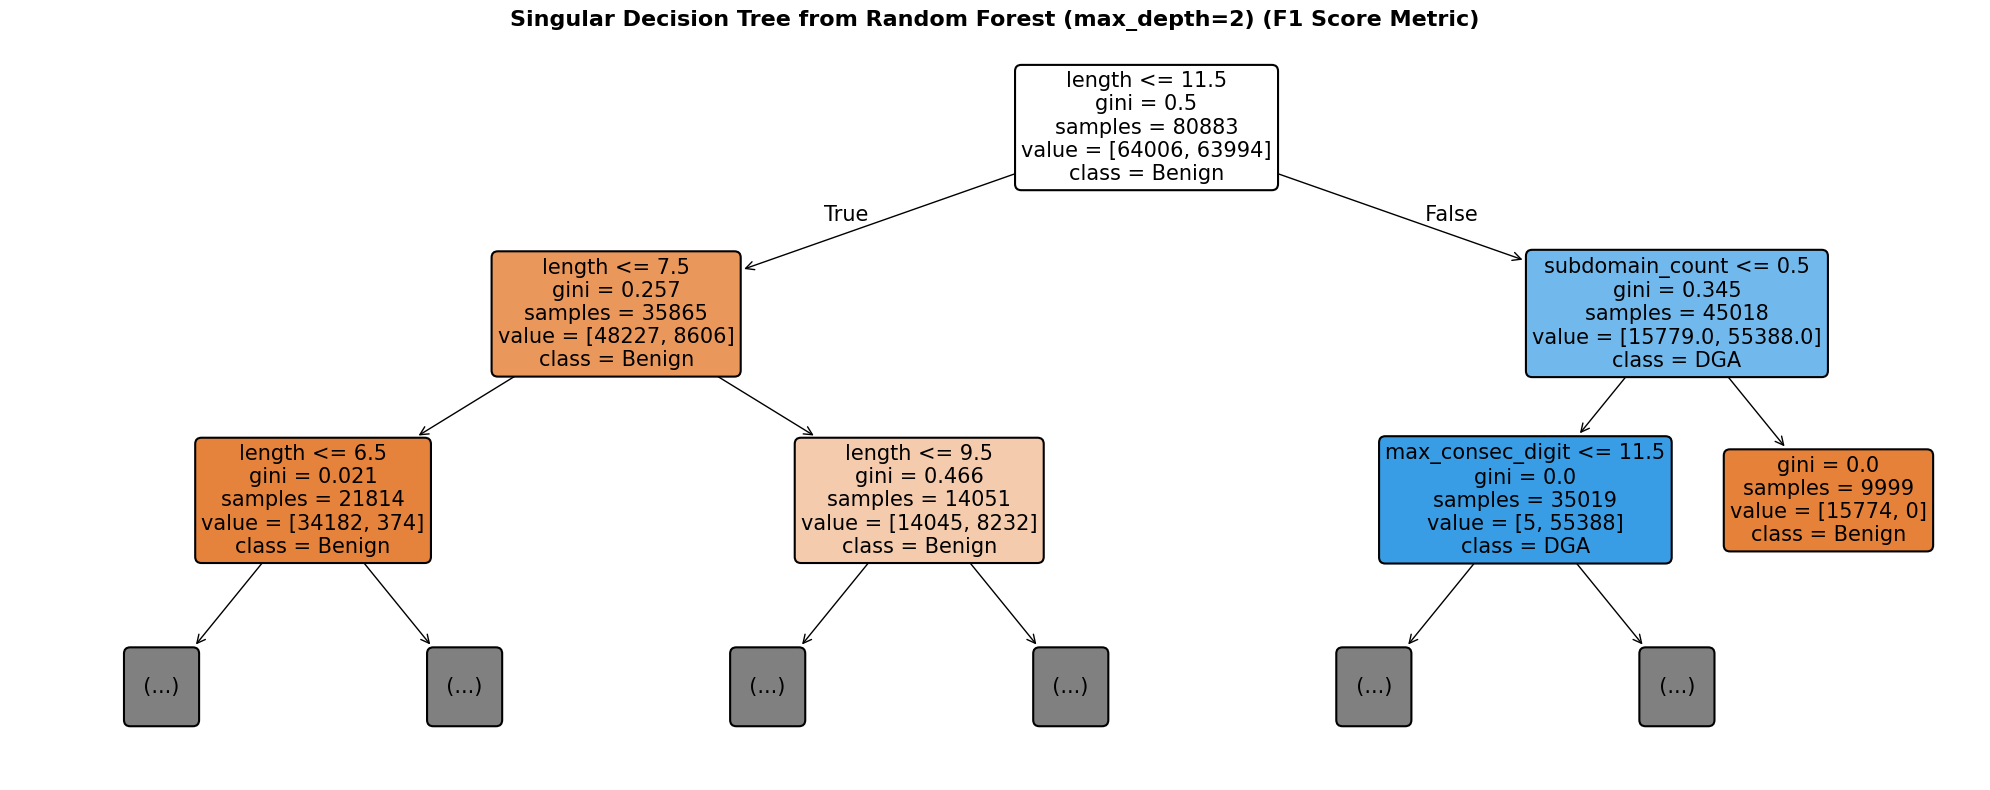

In [11]:
create_best_feature_importance(7, "F1 Score", "red")